# Amsterdam Student Housing Price Predictor
## Machine Learning Analysis

This notebook demonstrates the complete pipeline for predicting Amsterdam student housing prices using machine learning.

**Models Used:**
- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

## 1. Setup and Imports

In [1]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn imports
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Custom modules
import sys
sys.path.append('../src')
from data_preprocessing import HousingDataPreprocessor
from train_models import HousingPriceModels
from utils import *

# Settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("All imports successful!")

All imports successful!


## 2. Load and Explore Data

In [2]:
# Create sample dataset (replace with your actual data)
print("Creating sample dataset...")
df = create_sample_dataset(n_samples=1000)

print(f"Dataset shape: {df.shape}")
print("\nFirst few rows:")
df.head()

Creating sample dataset...
Dataset shape: (1000, 7)

First few rows:


,location,size,room_type,distance_to_uva,furnished,registration_possible,price
0,Oost,36,Private Room,8.51,0,1,948.87
1,Noord,35,Private Room,1.87,1,1,1071.92
2,Oud-West,84,Shared,5.48,0,0,1372.71
3,Noord,84,Private Room,4.60,0,1,1385.66
4,Noord,18,Studio,6.17,1,0,1074.80


In [3]:
# Summary statistics
get_summary_statistics(df)

=== Summary Statistics ===
              size  distance_to_uva    furnished  registration_possible  \
count  1000.000000      1000.000000  1000.000000            1000.000000   
mean     55.730000         7.814440     0.499000               0.676000   
std      24.321773         4.216601     0.500249               0.468234   
min      15.000000         0.500000     0.000000               0.000000   
25%      35.000000         4.112500     0.000000               0.000000   
50%      54.000000         8.025000     0.000000               1.000000   
75%      76.000000        11.510000     1.000000               1.000000   
max      99.000000        15.000000     1.000000               1.000000   

             price  
count  1000.000000  
mean   1362.441420  
std     261.580416  
min     639.000000  
25%    1172.455000  
50%    1352.235000  
75%    1549.345000  
max    2158.560000  

=== Data Types ===
location                  object
size                       int64
room_type             

## 3. Exploratory Data Analysis (EDA)

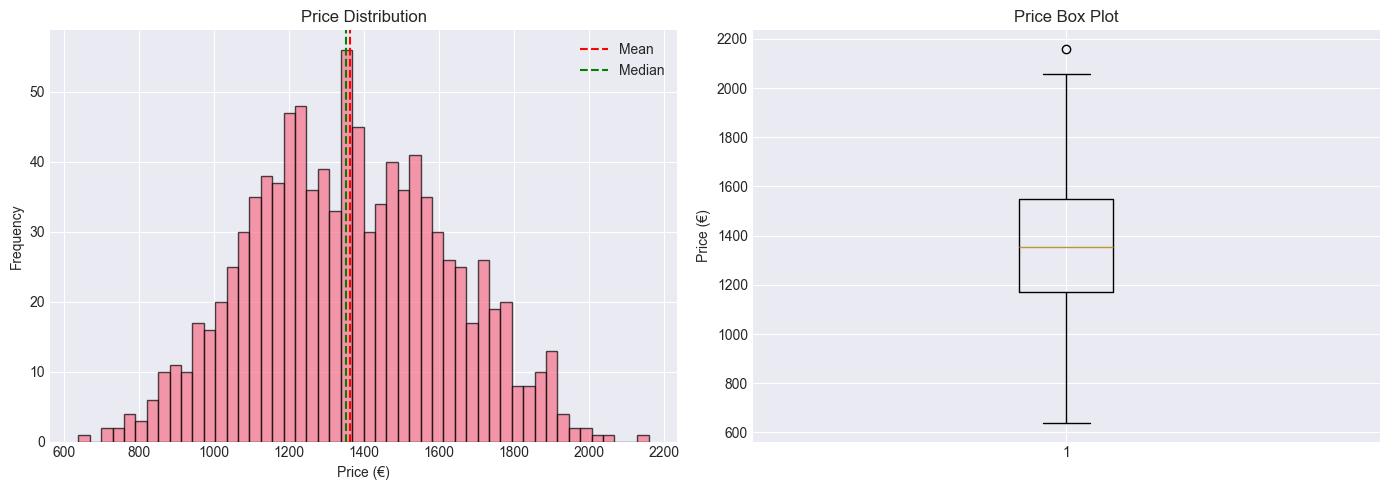

In [4]:
# Price distribution
plot_price_distribution(df)

In [5]:
# Price by location
location_metrics = calculate_price_metrics_by_location(df)
print("Price metrics by location:")
location_metrics

Price metrics by location:


,count,mean,median,std,min,max
location,,,,,,
Centrum,181,1504.21,1518.19,254.69,880.43,2158.56
De Pijp,164,1438.04,1471.71,250.55,894.54,2057.90
Zuid,155,1353.00,1331.15,247.36,720.41,1944.40
Oud-West,154,1335.50,1315.56,253.10,771.42,1994.53
Oost,174,1293.06,1278.92,235.34,773.33,1833.92
Noord,172,1244.00,1229.69,238.04,639.00,1950.55


<Figure size 1200x600 with 0 Axes>

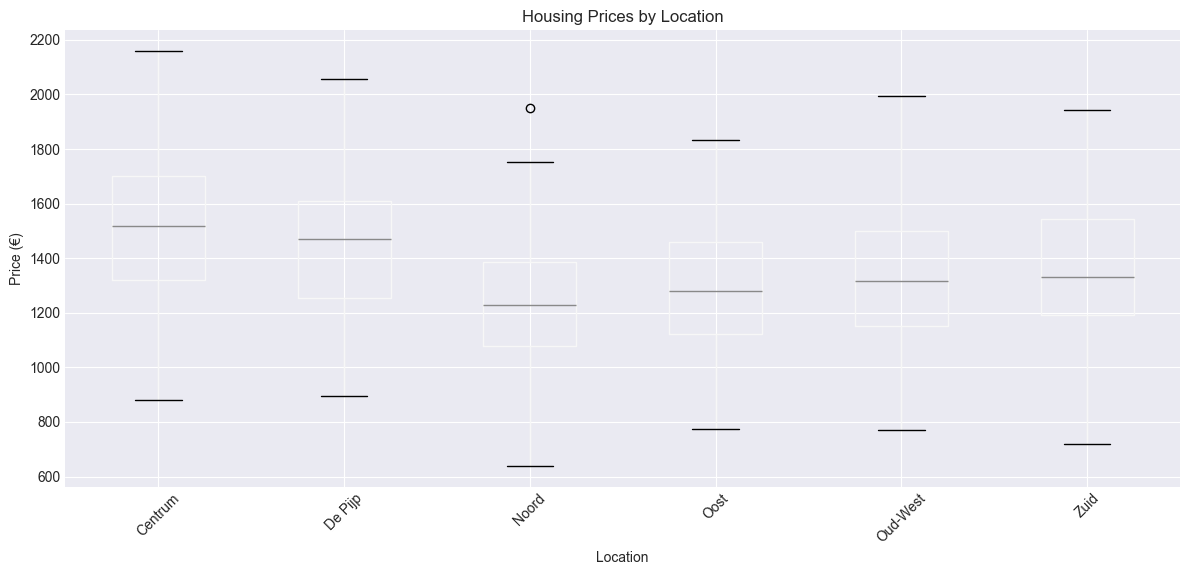

In [6]:
# Visualize price by location
plt.figure(figsize=(12, 6))
df.boxplot(column='price', by='location', figsize=(12, 6))
plt.xlabel('Location')
plt.ylabel('Price (€)')
plt.title('Housing Prices by Location')
plt.suptitle('')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

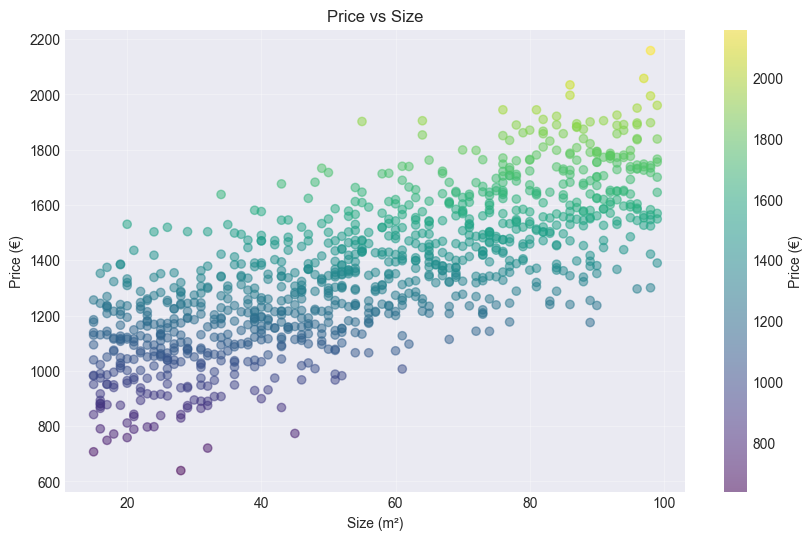

In [7]:
# Price vs Size
plt.figure(figsize=(10, 6))
plt.scatter(df['size'], df['price'], alpha=0.5, c=df['price'], cmap='viridis')
plt.xlabel('Size (m²)')
plt.ylabel('Price (€)')
plt.title('Price vs Size')
plt.colorbar(label='Price (€)')
plt.grid(True, alpha=0.3)
plt.show()

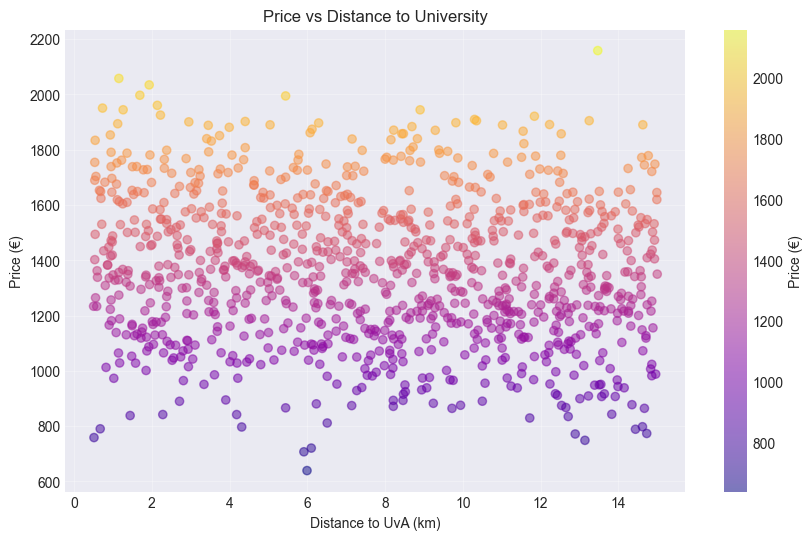

In [8]:
# Price vs Distance to UvA
plt.figure(figsize=(10, 6))
plt.scatter(df['distance_to_uva'], df['price'], alpha=0.5, c=df['price'], cmap='plasma')
plt.xlabel('Distance to UvA (km)')
plt.ylabel('Price (€)')
plt.title('Price vs Distance to University')
plt.colorbar(label='Price (€)')
plt.grid(True, alpha=0.3)
plt.show()

## 4. Data Preprocessing

In [9]:
# Initialize preprocessor
preprocessor = HousingDataPreprocessor()

# Clean data
df_clean = preprocessor.clean_data(df.copy())

# Feature engineering
df_engineered = preprocessor.feature_engineering(df_clean)

# Encode categorical variables
categorical_cols = ['location', 'room_type']
df_encoded = preprocessor.encode_categorical(df_engineered.copy(), categorical_cols)

print("Preprocessing completed!")
print(f"Final shape: {df_encoded.shape}")


=== Data Cleaning ===
Initial shape: (1000, 7)
Missing values:
location                 0
size                     0
room_type                0
distance_to_uva          0
furnished                0
registration_possible    0
price                    0
dtype: int64
After removing duplicates: (1000, 7)
After removing price outliers: (999, 7)
Final cleaned shape: (999, 7)

=== Feature Engineering ===
Features after engineering: ['location', 'size', 'room_type', 'distance_to_uva', 'furnished', 'registration_possible', 'price', 'price_per_sqm', 'distance_category', 'size_category']

=== Encoding Categorical Variables ===
Encoded: location
Encoded: room_type
Preprocessing completed!
Final shape: (999, 10)


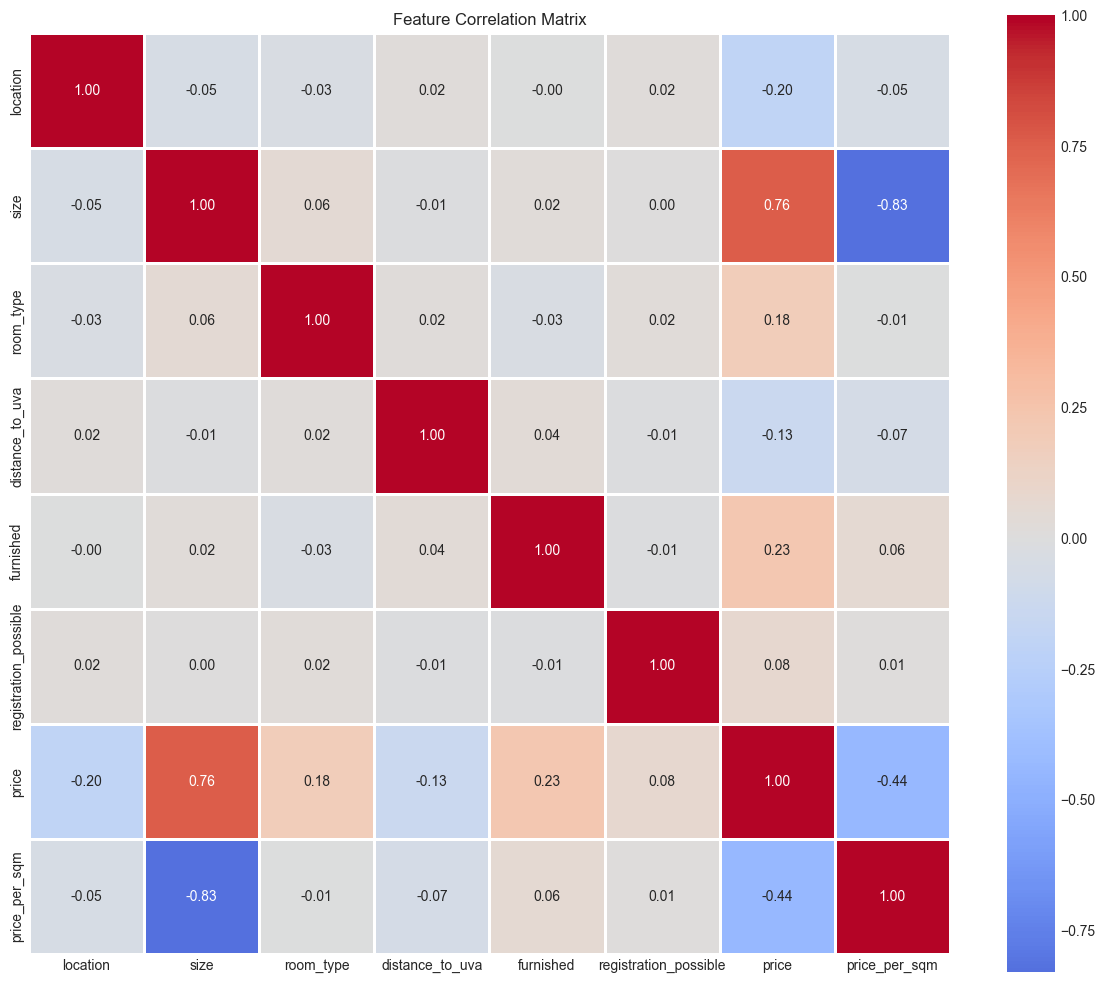

In [10]:
# Check correlation matrix
numeric_cols = df_encoded.select_dtypes(include=[np.number]).columns
corr_matrix = df_encoded[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=1)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [11]:
# Prepare features and target
X, y = preprocessor.prepare_features(df_encoded, target_col='price')

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {X.columns.tolist()}")


=== Preparing Features ===
Target column: price
Feature shape: (999, 9)
Target shape: (999,)
Features shape: (999, 9)
Target shape: (999,)

Feature columns: ['location', 'size', 'room_type', 'distance_to_uva', 'furnished', 'registration_possible', 'price_per_sqm', 'distance_category', 'size_category']


In [12]:
# Split data
X_train, X_test, y_train, y_test = preprocessor.split_data(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")


=== Splitting Data ===
Training set: 799 samples
Testing set: 200 samples
Training set: 799 samples
Testing set: 200 samples


## 5. Model Training and Evaluation

In [13]:
# Initialize models
housing_models = HousingPriceModels()
housing_models.initialize_models()

# Train all models
housing_models.train_all_models(X_train, y_train, X_test, y_test)

=== Initializing Models ===
Initialized 3 models:
  - Linear Regression
  - Decision Tree
  - Random Forest

Training All Models

Training Linear Regression...


ValueError: could not convert string to float: 'Close'

## 6. Model Comparison and Visualization

In [ ]:
# Plot predictions vs actual
housing_models.plot_predictions(y_test)

In [ ]:
# Plot residuals
housing_models.plot_residuals(y_test)

In [ ]:
# Feature importance for Random Forest
housing_models.feature_importance(X_train, 'Random Forest', top_n=10)

In [ ]:
# Feature importance for Decision Tree
housing_models.feature_importance(X_train, 'Decision Tree', top_n=10)

## 7. Model Performance Summary

In [ ]:
# Create performance comparison dataframe
performance_df = pd.DataFrame({
    'Model': list(housing_models.results.keys()),
    'Train RMSE': [housing_models.results[m]['train_rmse'] for m in housing_models.results],
    'Test RMSE': [housing_models.results[m]['test_rmse'] for m in housing_models.results],
    'Test MAE': [housing_models.results[m]['test_mae'] for m in housing_models.results],
    'Test R²': [housing_models.results[m]['test_r2'] for m in housing_models.results],
    'CV RMSE': [housing_models.results[m]['cv_rmse'] for m in housing_models.results]
})

performance_df = performance_df.sort_values('Test RMSE')
print("\nModel Performance Comparison:")
performance_df

In [ ]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE comparison
axes[0].bar(performance_df['Model'], performance_df['Test RMSE'])
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Test RMSE (€)')
axes[0].set_title('Model Comparison - RMSE')
axes[0].tick_params(axis='x', rotation=45)

# R² comparison
axes[1].bar(performance_df['Model'], performance_df['Test R²'])
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Test R²')
axes[1].set_title('Model Comparison - R² Score')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 8. Conclusions and Key Learnings

### Key Findings:
1. **Model Performance**: [To be filled after running the analysis]
2. **Most Important Features**: [To be filled after running the analysis]
3. **Insights**: [To be filled after running the analysis]

### Technical Learnings:
- Implemented three different regression algorithms from scratch
- Performed comprehensive exploratory data analysis
- Applied feature engineering techniques
- Compared model performance using multiple metrics (RMSE, R², MAE)
- Used cross-validation for robust performance estimates
- Analyzed feature importance in tree-based models

### Future Improvements:
- Hyperparameter tuning using GridSearchCV
- Try additional models (XGBoost, Neural Networks)
- Collect more real-world data
- Add temporal features (time of year, market trends)
- Deploy model as a web application

In [ ]:
# Save the trained models
housing_models.save_models('../models')
print("\nAll models saved successfully!")